# DSCI Project: Individual Planning Report

Library Required: tidyverse, repr

In [4]:
library(tidyverse)
library(repr)

## 1) Data Description

### players.csv

Overview: This dataset contains a list of players' personal information.

Number of Observations: 196

Number of Variables: 7

Variable Information:
| **Variable** | **Type** | **Description** |
|---------------|-----------|----------------|
| `experience` | Character | Player's skill level: one of *Beginner*, *Regular*, *Amateur*, *Pro*, or *Veteran*. |
| `subscribe` | Logical | Whether the player is subscribed to the newsletter. |
| `hashedEmail` | Character | The player's hashed email address. |
| `played_hours` | Numeric | Player's total playtime in hours. |
| `name` | Character | The player's name. |
| `gender` | Character | The player's gender. |
| `Age` | Numeric | The player's age in years. |

Collection Methods:
- `hashedEmail` and `played_hours` were likely collected from the game server's session log.
- The other variables were collected via surveys.

Potential Issues regarding variables
- `Age` has 2 missing values (code below)
- `gender` has many observations that are `Prefer not to say`, which is similar to missing values.

Potential Issues regarding the collection method
- The classification of a player's `experience` is ambiguous, as a player can be skilled in different areas of the game (e.g. pve, pvp)
- We assume all players provided real data


Summary Statistics of numeric variables, `Age` and `played_hours` (Calculations in code cells below):
| Variable      | Mean      | Std       | Min | Max  |
|---------------|----------|----------|-----|------|
| played_hours  | 5.85 | 28.36 | 0   | 223.1|
| Age           | 21.14 | 7.39 | 9   | 58   |





In [5]:
#Load Data
players <- read_csv('data/players.csv')

#Detect Missing Values
players |>  summarise(across(everything(), ~ sum(is.na(.x))))

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<int>,<int>,<int>,<int>,<int>,<int>,<int>
0,0,0,0,0,0,2


In [6]:
# Calculate Mean
cat("=== Mean Summary ===\n")
players |>  summarise(across(where(is.numeric), ~ mean(.x, na.rm = TRUE)))


# Calculate Standard Deviation
cat("=== Standard Deviation Summary ===\n")
players |>  summarise(across(where(is.numeric), ~ sd(.x, na.rm = TRUE)))

# Find Minimum
cat("=== Minimum Summary ===\n")
players |> summarise(across(where(is.numeric), ~ min(.x, na.rm = TRUE)))

# Find Maximum
cat("=== Maximum Summary ===\n")
players |> summarise(across(where(is.numeric), ~ max(.x, na.rm = TRUE)))

=== Mean Summary ===


played_hours,Age
<dbl>,<dbl>
5.845918,21.13918


=== Standard Deviation Summary ===


played_hours,Age
<dbl>,<dbl>
28.35734,7.389687


=== Minimum Summary ===


played_hours,Age
<dbl>,<dbl>
0,9


=== Maximum Summary ===


played_hours,Age
<dbl>,<dbl>
223.1,58


### session.csv

Overview: This dataset contains a list of information on each recorded play session.

Number of Observations: 1535

Number of Variables: 5

Variable Information:
| **Variable** | **Type** | **Description** |
|---------------|-----------|----------------|
| `hashedEmail` | Character | The player's hashed email address. |
| `start_time` | Character | The start time of the play session |
| `end_time` | Character | The end time of the play session. |
| `original_start_time` | Numeric | UNIX timestamp of start time (milliseconds since epoch) |
| `original_end_time` | Numeric | UNIX timestamp of start time (milliseconds since epoch) |

Collection Methods:
- Data were likely collected via the game server's session log.

Potential Issues regarding variables
- `original_start_time` and `original_end_time` appear to represent UNIX timestamps, but this cannot be confirmed without further details regarding how this variable is used.
- Both `end_time` and `original_end_time` have 2 missing values (code below).
- Both `end_time` and `start_time` are character data types.  This is not ideal for time analysis in R.
- For some observations, `original_start_time` and `original_end_time` are identical due to rounding, resulting in sessions that appear to have a duration of zero hours..  This may make these 2 variables less useful for time analysis.

Potential Issues regarding the collection method
- Unsure if time data was collected in the same timezone


Summary Statistics of numeric variables, `original_start_time` and `original_end_time`:
- As the 2 variables represent time, summary statistics will not be meaningful






## 2) Questions

Broad Question 2: We would like to know which "kinds" of players are most likely to contribute a large amount of data so that we can target those players in our recruiting efforts.

My Question: Can a player's `Age` predict the player's `played_time` in `players.csv`?

How will the dataset help:
- `players.csv` contains information on participants' age and play time.
- We can create a regression model using `Age` as the explanatory variable to predict `played_time`, then calculate how good the model performed using metrics such as RMSPE, Pearson coefficient, etc.
- Some observations for age are missing. Since these observations do not contain the explanatory variable, they will be omitted before the analysis.

## 3) Exploratory Data Analysis and Visualization

In [12]:
# Load players.csv
options(repr.matrix.max.rows = 4)
players <- read_csv('data/players.csv')
players 

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


In [14]:
# Data Wrangling (Minimumly Necessary): remove observations that has missing Age variable
players_wrangled <- players |>
                        filter(Age != 'NA')
players_wrangled

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17


In [16]:
# Calculate the mean of each variable
means <- players_wrangled |>  summarise(across(where(is.numeric), ~ mean(.x)))
means

played_hours,Age
<dbl>,<dbl>
5.904639,21.13918


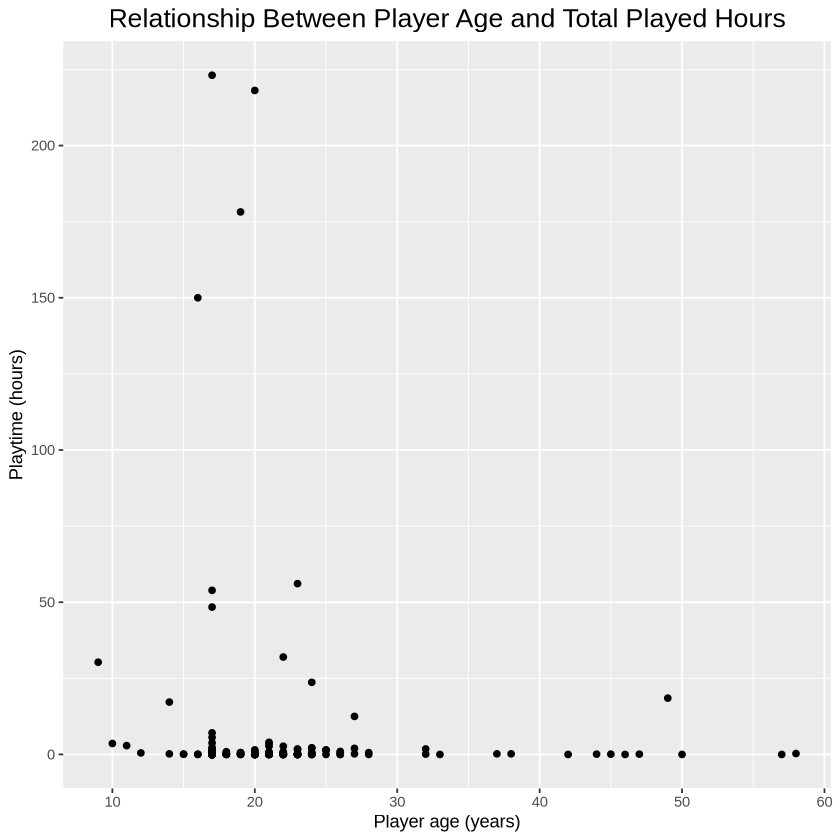

In [26]:
# Exploratory Visualization: Played_hours vs Age
players_scatterplot <- players_wrangled |> ggplot(aes(x = Age, y = played_hours)) +
                                    geom_point() +
                                        labs(x = 'Player age (years)', y = 'Playtime (hours)', title = 'Relationship Between Player Age and Total Played Hours') +
                                            theme(plot.title = element_text(hjust = 0.5, size = 16))
players_scatterplot

The scatterplot plotted `played_hours` against `Age`.  No obvious trend was seen between the variables, although the highest recorded playtime mainly clusters among players aged between 10 and 30, and this maximum decreases as player gets older.

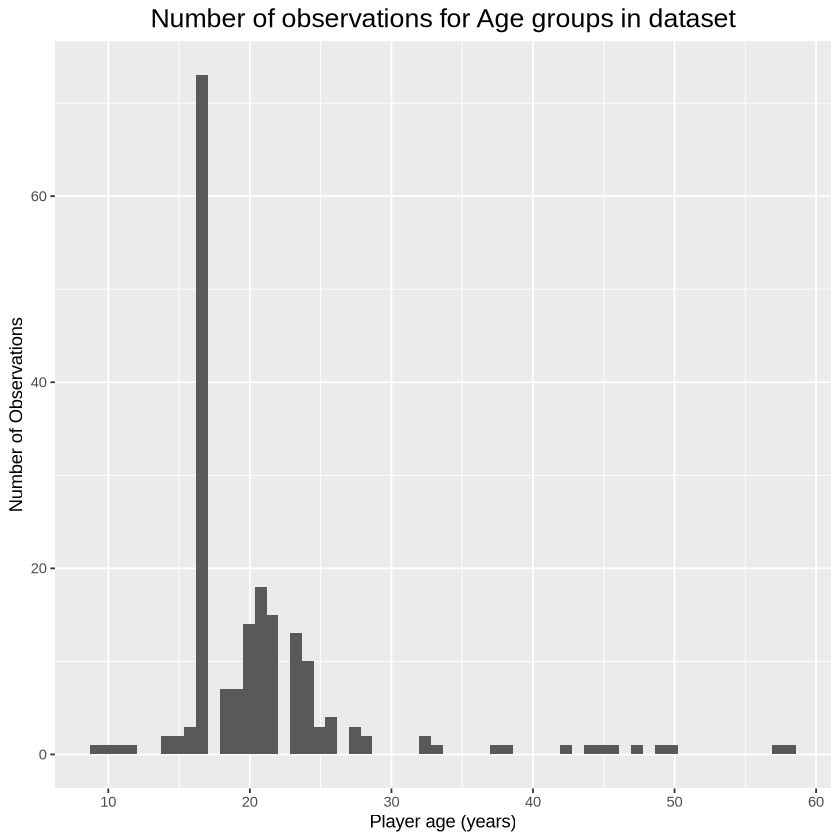

In [47]:
players_histogram <- players_wrangled |> ggplot(aes(x = Age)) +
                                    geom_histogram(bins = 60) +
                                        labs(x = 'Player age (years)', y = 'Number of Observations', title = 'Number of observations for Age groups in dataset') + 
                                            scale_x_continuous(breaks = seq(0, 60, by = 10)) + 
                                            theme(plot.title = element_text(hjust = 0.5, size = 16))
players_histogram

The histogram above shows that most participating players are between 15 and 25 years old.  This may be a problem for the KNN Regression Model as the closest neighbour for higher player ages will be from lower age groups, leading to unreliable predictions.

## 4) Methods and Plan



To answer the proposed question:
- Two regression models, linear and K-Nearest Neighbour, will be trained using 70% of the observations in `player.csv`, while the rest 30% will be used for testing (compare model prediction against true values)
- Cross-validation will be used to get a non-biased statistical rating for both models.  5 folds will be created for this purpose from `player.csv`.
- Statistical metrics, such as RMSPE and R$^2$, will be calculated based on the predictions and the true values.  These metrics will help us determine if the regression models are useful and whether we can use player age to predict playtime.

Why are the methods appropriate:
- We are using a scaler to predict another scaler.  Therefore, using regression models to predict 

Assumptions:
- Linear Regression assumes a potential linear relationship between the variables
- KNN Regression assumes that nearby data points have similar `played_time` values
- Both models assume that the data were true (i.e. the participants did not lie)

Limitations:
Initial visualizations in part 3 show:
- No obvious linear trend between the 2 variables.  Linear regression may fail to produce accurate predictions.
- Most data points lie within a 10 - 30-year-old range, meaning the closest neighbour may not

Choosing the best model:
- RMPSE will be used to determine the best prediction model
- (Pick a Model)
